In [1]:
import pandas as pd

import scarf

scarf.configure_output(level='WARNING', progress=True)

In [2]:
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name='bastidas-ponce_4K_pancreas-d15_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)

ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    default_assay='RNA',
    nthreads=4,
)

ds

Downloading bucket files: 37077563 / 37077563 complete

Downloading bytes: 37077563 / 37077563 complete

DataStore has 3696 (3696) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'X_umap1', 'G2M_score', 
            'RNA_percentMito', 'RNA_nFeatures', 'RNA_clusters', 'RNA_nCounts', 'RNA_percentRibo', 
            'clusters_coarse', 'S_score', 'X_umap2', 'RNA_leiden_cluster', 'RNA_UMAP2', 
            'RNA_UMAP1', 'clusters'
   RNA assay has 12682 (27998) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'I__hvgs', 
            'dropOuts', 'highly_variable_genes'

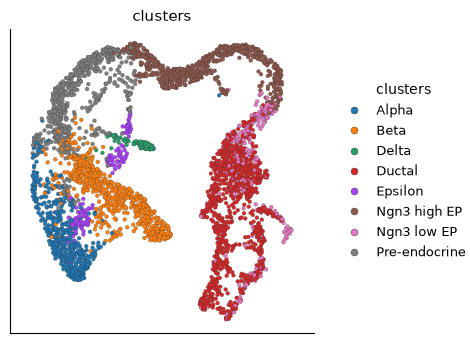

In [3]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='clusters',
)

In [4]:
ds.show_zarr_tree(depth=1)

/
├── RNA
│   ├── artifacts
│   ├── counts (3696, 27998) uint16
│   ├── featureData
│   ├── markers
│   ├── state
│   └── summary_stats_I
├── artifacts
│   ├── cell_selection
│   └── metadata_snapshot
└── cellData
    ├── G2M_score (3696,) float32
    ├── I (3696,) bool
    ├── RNA_UMAP1 (3696,) float32
    ├── RNA_UMAP2 (3696,) float32
    ├── RNA_clusters (3696,) int64
    ├── RNA_leiden_cluster (3696,) int64
    ├── RNA_nCounts (3696,) float64
    ├── RNA_nFeatures (3696,) float64
    ├── RNA_percentMito (3696,) float64
    ├── RNA_percentRibo (3696,) float64
    ├── S_score (3696,) float32
    ├── X_umap1 (3696,) float32
    ├── X_umap2 (3696,) float32
    ├── clusters (3696,) <U13
    ├── clusters_coarse (3696,) <U13
    ├── ids (3696,) <U19
    └── names (3696,) <U19



In [5]:
ds.show_zarr_tree(start='cellData')

/cellData
├── G2M_score (3696,) float32
├── I (3696,) bool
├── RNA_UMAP1 (3696,) float32
├── RNA_UMAP2 (3696,) float32
├── RNA_clusters (3696,) int64
├── RNA_leiden_cluster (3696,) int64
├── RNA_nCounts (3696,) float64
├── RNA_nFeatures (3696,) float64
├── RNA_percentMito (3696,) float64
├── RNA_percentRibo (3696,) float64
├── S_score (3696,) float32
├── X_umap1 (3696,) float32
├── X_umap2 (3696,) float32
├── clusters (3696,) <U13
├── clusters_coarse (3696,) <U13
├── ids (3696,) <U19
└── names (3696,) <U19

  RNA_percentMito: shape=(3696,), dtype=float64, chunks=(100000,)
  RNA_percentRibo: shape=(3696,), dtype=float64, chunks=(100000,)
  X_umap1: shape=(3696,), dtype=float32, chunks=(100000,)
  RNA_nFeatures: shape=(3696,), dtype=float64, chunks=(100000,)
  RNA_clusters: shape=(3696,), dtype=int64, chunks=(100000,)
  G2M_score: shape=(3696,), dtype=float32, chunks=(100000,)
  RNA_nCounts: shape=(3696,), dtype=float64, chunks=(100000,)
  names: shape=(3696,), dtype=<U19, chunks=(100000

In [6]:
ds.cells.to_pandas_dataframe(['I'])['I'].value_counts()

I
True    3696
Name: count, dtype: int64

In [7]:
ds.show_zarr_tree(start='RNA', depth=1)

/RNA
├── artifacts
│   ├── ann_index
│   ├── cluster_labels
│   ├── connectivity_map
│   ├── embedding
│   ├── embedding_initialization
│   ├── feature_scaling
│   ├── feature_selection
│   ├── marker_table
│   ├── neighbors
│   ├── normalized
│   └── reduction
├── counts (3696, 27998) uint16
├── featureData
│   ├── I (27998,) bool
│   ├── I__hvgs (27998,) bool
│   ├── dropOuts (27998,) int64
│   ├── highly_variable_genes (27998,) <U8
│   ├── ids (27998,) <U18
│   ├── nCells (27998,) int64
│   └── names (27998,) <U18
├── markers
├── state
└── summary_stats_I
    ├── avg (27998,) float64
    ├── c_var__adaptive__200__0.1 (27998,) float64
    ├── normed_n (27998,) float64
    ├── normed_tot (27998,) float64
    ├── nz_mean (27998,) float64
    └── sigmas (27998,) float64

  counts: shape=(3696, 27998), dtype=uint16, chunks=(3696, 13999), shards=(3696, 27998)


In [8]:
ds.show_zarr_tree(start='RNA/featureData', depth=1)

/RNA/featureData
├── I (27998,) bool
├── I__hvgs (27998,) bool
├── dropOuts (27998,) int64
├── highly_variable_genes (27998,) <U8
├── ids (27998,) <U18
├── nCells (27998,) int64
└── names (27998,) <U18

  names: shape=(27998,), dtype=<U18, chunks=(100000,)
  nCells: shape=(27998,), dtype=int64, chunks=(100000,)
  highly_variable_genes: shape=(27998,), dtype=<U8, chunks=(100000,)
  I: shape=(27998,), dtype=bool, chunks=(100000,)
  I__hvgs: shape=(27998,), dtype=bool, chunks=(100000,)
  dropOuts: shape=(27998,), dtype=int64, chunks=(100000,)
  ids: shape=(27998,), dtype=<U18, chunks=(100000,)


In [9]:
ds.show_zarr_tree(start='RNA/artifacts', depth=1)

/RNA/artifacts
├── ann_index
│   └── 332cb78d39e3661cdd43342fc5ec6c018da2985dbb17f3ee92fc01f2cb314072
├── cluster_labels
│   └── 9660580f0df38601d9a278df263a42a0b950fa1a3281d9c33f387b0320f60d8b
├── connectivity_map
│   └── eaec38a538b226be7e949906b5b902a73167cda2f70034e8f2f7cce170440fb2
├── embedding
│   └── 335746d806e731ad9b4975ad136762f677dd2aa91d187f2a98a852d40387504e
├── embedding_initialization
│   └── a0dcea89a3973951058e711c5b2c0292b0f6307a65b1db6ceb531e73de526bf3
├── feature_scaling
│   └── c8ddd98d66c17872fa295becb83cba94059cc6b54fcbcfe5654281fde4aaff7a
├── feature_selection
│   ├── 9f0458d51e0a0a7b14fe910efe9aafb07cc9801e86f3549668d1bce07a601268
│   └── df89865bfa7d64e127bc2f5fdbde5279a4f854b62644ee60c9d11d7efb8fb8fa
├── marker_table
│   └── 6de20234177e66b2e494997bb05816d17bfbb3dd571c9a356032be30e05c4458
├── neighbors
│   └── 3d7a8d04ba1b3ec33383b6bfd3ba2b5e73b4bd7364b768d03db17292e58eef59
├── normalized
│   └── 389ebcc69c9955859ff67945defb76869e5d0c55e83a175d10caa47493afec

In [10]:
ds.cells.head()

,I,ids,names,RNA_percentMito,G2M_score,X_umap1,RNA_clusters,clusters_coarse,RNA_percentRibo,RNA_UMAP2,RNA_nFeatures,RNA_leiden_cluster,X_umap2,S_score,clusters,RNA_UMAP1,RNA_nCounts
0,True,AAACCTGAGAGGGATA,AAACCTGAGAGGGATA,0.706500,-0.252071,6.143066,5,Pre-endocrine,15.563181,5.178569,2356.0,5,-0.063644,-0.224902,Pre-endocrine,-23.474279,4954.0
1,True,AAACCTGAGCCTTGAT,AAACCTGAGCCTTGAT,1.286947,-0.232610,-9.906417,1,Ductal,30.632160,-5.490222,2613.0,1,0.197778,-0.014707,Ductal,16.789351,7071.0
2,True,AAACCTGAGGCAATTA,AAACCTGAGGCAATTA,0.687961,-0.286834,7.559791,5,Endocrine,19.041769,-6.202672,1984.0,5,0.583762,-0.171255,Alpha,-29.374493,4070.0
3,True,AAACCTGCATCATCCC,AAACCTGCATCATCCC,1.195886,0.191243,-11.283765,6,Ductal,28.653432,-22.689632,2860.0,6,4.218998,0.599244,Ductal,12.077156,8362.0
4,True,AAACCTGGTAAGTGGC,AAACCTGGTAAGTGGC,1.094310,-0.126030,1.721565,7,Ngn3 high EP,19.419021,23.814350,2211.0,7,-4.753407,-0.179981,Ngn3 high EP,-7.740653,5026.0


In [11]:
ds.RNA.feats.head()

,I,ids,names,nCells,I__hvgs,dropOuts,highly_variable_genes
0,False,Xkr4,Xkr4,6,False,3690,False
1,False,Gm37381,Gm37381,0,False,3696,None
2,False,Rp1,Rp1,0,False,3696,None
3,False,Rp1-1,Rp1-1,0,False,3696,None
4,False,Sox17,Sox17,0,False,3696,None


In [12]:
ds.cells.to_pandas_dataframe(
    columns=['ids', 'RNA_nCounts', 'RNA_nFeatures', 'clusters']
).set_index('ids')

,RNA_nCounts,RNA_nFeatures,clusters
ids,,,
AAACCTGAGAGGGATA,4954.0,2356.0,Pre-endocrine
AAACCTGAGCCTTGAT,7071.0,2613.0,Ductal
AAACCTGAGGCAATTA,4070.0,1984.0,Alpha
AAACCTGCATCATCCC,8362.0,2860.0,Ductal
AAACCTGGTAAGTGGC,5026.0,2211.0,Ngn3 high EP
...,...,...,...
TTTGTCAAGTGACATA,9219.0,3283.0,Pre-endocrine
TTTGTCAAGTGTGGCA,7298.0,2605.0,Ngn3 high EP
TTTGTCAGTTGTTTGG,5234.0,2168.0,Ductal


In [13]:
cluster_labels = ds.cells.fetch('clusters')
first_cluster = str(cluster_labels[0])
is_first_cluster = cluster_labels.astype(str) == first_cluster
ds.cells.insert(column_name='is_first_cluster', values=is_first_cluster, overwrite=True)

In [14]:
ds.cells.to_pandas_dataframe(
    columns=['ids', 'clusters', 'is_first_cluster']
).head()

,ids,clusters,is_first_cluster
0,AAACCTGAGAGGGATA,Pre-endocrine,True
1,AAACCTGAGCCTTGAT,Ductal,False
2,AAACCTGAGGCAATTA,Alpha,False
3,AAACCTGCATCATCCC,Ductal,False
4,AAACCTGGTAAGTGGC,Ngn3 high EP,False


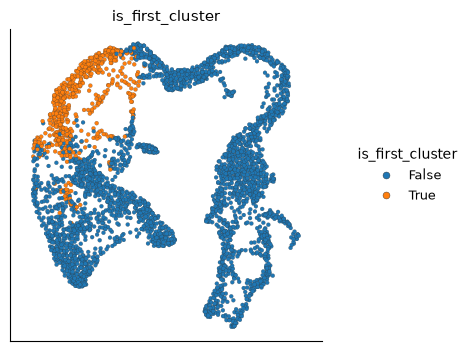

In [15]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='is_first_cluster',
)

In [16]:
i_backup = ds.cells.fetch_all('I').copy()
ds.cells.update_key(is_first_cluster, 'I')

print(
    'fetch:', ds.cells.fetch('clusters').shape,
    'fetch_all:', ds.cells.fetch_all('clusters').shape,
)
ds.cells.to_pandas_dataframe(['I'])['I'].value_counts()

fetch: (592,) fetch_all: (3696,)


I
False    3104
True      592
Name: count, dtype: int64

In [17]:
ds.cells.insert(column_name='I', values=i_backup, overwrite=True, force=True)
print('Restored active cells:', int(ds.cells.fetch_all('I').sum()))

Restored active cells: 3696


In [18]:
try:
    ds.cells.insert(
        column_name='is_first_cluster',
        values=is_first_cluster,
    )
except ValueError:
    print("Expected validation: use overwrite=True to replace an existing column.")

Expected validation: use overwrite=True to replace an existing column.


In [19]:
active_before = int(ds.cells.fetch_all('I').sum())
count_range = ds.cells.sift(
    'RNA_nCounts',
    min_v=1000,
    max_v=15000,
)
joint_range = ds.cells.multi_sift(
    columns=['RNA_nCounts', 'RNA_nFeatures'],
    lows=[1000, 500],
    highs=[15000, 4000],
)
cluster_rows = ds.cells.get_index_by([first_cluster], 'clusters')

print(
    'count_range:', int(count_range.sum()),
    'joint_range:', int(joint_range.sum()),
    'cluster_rows:', int(cluster_rows.size),
)
print('Active cells (I) before:', active_before)
print('Active cells (I) after:', int(ds.cells.fetch_all('I').sum()))

count_range: 3669 joint_range: 3667 cluster_rows: 592
Active cells (I) before: 3696


Active cells (I) after: 3696


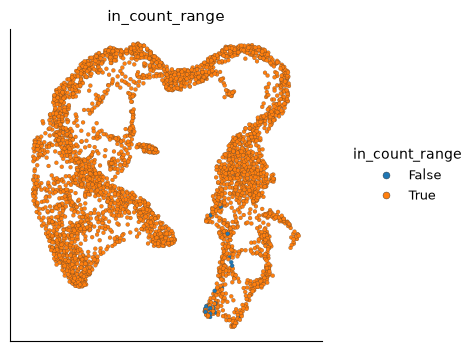

In [20]:
ds.cells.insert(column_name='in_count_range', values=count_range, overwrite=True)
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='in_count_range',
)

In [21]:
ds.RNA.rawData

ChunkedArray(shape=(3696, 27998), dtype=uint16, chunksize=(3696, 27998), numblocks=1)

In [22]:
ds.RNA.normed()

ChunkedArray(shape=(3696, 12682), dtype=float64, chunksize=(3696, 12682), numblocks=1)

In [23]:
print('Raw shape:', ds.RNA.rawData.shape)
print('Normed shape:', ds.RNA.normed().shape)
ds.RNA.rawData[:3, :5].compute()

Raw shape: (3696, 27998)
Normed shape: (3696, 12682)


array([[0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0]], dtype=uint16)

In [24]:
ds.RNA.normed()[:3, :5].compute()

array([[0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.14142271, 0.        , 0.14142271, 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ]])

In [25]:
print('Current method:', ds.RNA.normMethod.__name__)

Current method: norm_lib_size


In [26]:
normalized = ds.run_normalization(feat_key='hvgs')
normalized

ArtifactRef(assay='RNA', kind='normalized', artifact_id='389ebcc69c99...')

In [27]:
status = ds.inspect_artifact(normalized)
print('Complete:', status.complete)
print('Operation:', status.operation)
print('Parameters:', status.parameters)

group = ds.load_artifact(normalized)
print('Arrays:', list(group.array_keys())[:5])

Complete: True
Operation: run_normalization
Parameters: {'normalization_method': {'external_hook': True, 'module': 'scarf.assay', 'qualname': 'norm_lib_size'}, 'size_factor': 1000.0, 'log_transform': True, 'renormalize_subset': True}
Arrays: ['feature_sum', 'data', 'feature_squared_sum']


In [28]:
index = dict(ds.z['RNA/markers'].attrs.get('artifacts', {}))
index

{'I__clusters': {'type': 'artifact',
  'scope': 'assay',
  'kind': 'marker_table',
  'artifact_id': '6de20234177e66b2e494997bb05816d17bfbb3dd571c9a356032be30e05c4458',
  'assay': 'RNA'}}

In [29]:
table = scarf.ArtifactRef.from_dict(index['I__clusters'])
print('Stored at:', ds.inspect_artifact(table).path)

Stored at: RNA/artifacts/marker_table/6de20234177e66b2e494997bb05816d17bfbb3dd571c9a356032be30e05c4458


In [30]:
ds.get_markers(
    group_key='clusters',
    group_id=ds.cells.fetch('clusters')[0],
    min_score=0.1,
    min_frac_exp=0.1,
).head()

,group_id,feature_name,feature_index,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value,auc,p_value_adjusted
0,Pre-endocrine,Slc35d3,1776,0.56161,0.08169,0.01069,0.29392,0.05735,7.64194,1.457781e-77,0.62293,2.801149e-75
1,Pre-endocrine,Srl,8669,0.46607,0.03705,0.00693,0.14696,0.04220,5.34870,1.003498e-24,0.55428,2.480772e-23
2,Pre-endocrine,Blnk,11524,0.46113,0.03881,0.00655,0.15541,0.03930,5.92376,2.541388e-30,0.55998,8.393200e-29
3,Pre-endocrine,Vdr,8144,0.46089,0.10130,0.01797,0.35642,0.08795,5.63646,2.156268e-78,0.64228,4.340601e-76
4,Pre-endocrine,Pcyt1b,27011,0.45875,0.12867,0.02256,0.41216,0.11050,5.70222,3.851160e-87,0.66301,9.768083e-85


Aggregating marker values per group: 1 / 1 complete

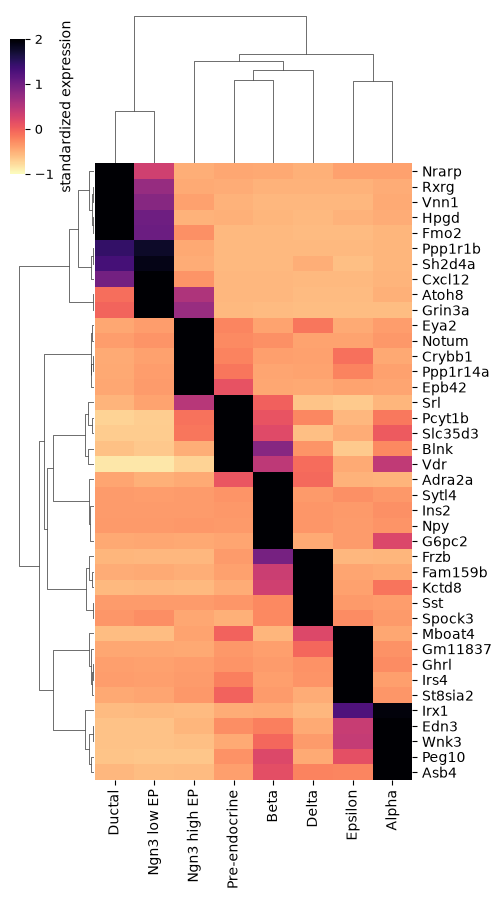

In [31]:
ds.plots.marker_heatmap(
    group_key='clusters',
    topn=5,
    figsize=(5, 9),
)

In [32]:
markers_csv = 'scarf_datasets/pancreas_cluster_markers.csv'
ds.export_markers_to_csv(
    group_key='clusters',
    csv_filename=markers_csv,
    min_score=0.1,
    min_frac_exp=0.1,
)
pd.read_csv(markers_csv).iloc[:5, :6]

,Alpha,Beta,Delta,Ductal,Epsilon,Ngn3 high EP
0,Asb4,Sytl4,Sst,Nrarp,Gm11837,Notum
1,Peg10,Ins2,Fam159b,Hpgd,Ghrl,Ppp1r14a
2,Wnk3,G6pc2,Kctd8,Vnn1,St8sia2,Crybb1
3,Irx1,Npy,Spock3,Fmo2,Irs4,Epb42
4,Edn3,Adra2a,Frzb,Rxrg,Mboat4,Eya2
